In [ ]:
%load_ext pretty_jupyter

# Data Preprocessing using Python

When working with a new dataset, whether you're preparing it for analysis, machine learning modelling, or regression tasks, the first and most crucial step is data preprocessing. This process ensures the dataset is clean, consistent, and ready for accurate insights. Data preprocessing involves exploring the data, addressing missing values, detecting outliers, and transforming variables to appropriate formats where necessary.

This section will walk through step-by-step procedures for data exploration and exploratory data analysis (EDA) using **Python**. We’ll leverage core libraries such as `pandas` for data manipulation and `matplotlib` and `seaborn` for visualizing distributions and relationships. Additionally, we’ll utilize tools like `sklearn.impute` to manage missing values effectively.

Following this guide, you will gain a solid understanding of foundational data preprocessing and EDA techniques. These steps are critical for ensuring your dataset is well-prepared and reliable, serving as the basis for advanced analyses, including machine learning and regression modelling.

So, we begin by importing the necessary libraries and loading the dataset.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from scipy.stats import skew, kurtosis

## Loading a dataset

Let's get a dataset to explore. We shall use the Kaggle Credit Test dataset, including 50,000 observations (rows) and 27 variables (columns). You can access the data file from here: [Kaggle_credit_test.csv](https://github.com/datasquad/ECLR/blob/gh-pages/data/Kaggle_credit_test.csv). This particular dataset includes financial and behavioural attributes of customers, such as income, debt, and payment habits. The variables included in the dataset and their desciption are as follows:
- `ID`: Unique identifier for each record.
- `Customer_ID`: Identifier for individual customers.
- `Month`: The month associated with the record.
- `Name`: Customer name.
- `Age`: Age of the customer.
- `SSN`: Social Security Number (likely pseudonymized).
- `Occupation`: Job or profession of the customer 
- `Annual_Income`: Annual income of the customer.
- `Monthly_Inhand_Salary`: Calculated monthly salary in hand.
- `Num_Bank_Accounts`: Number of bank accounts the customer owns.
- `Num_Credit_Cards`: Number of credit cards the customer owns.
- `Interest_Rate`: Interest rate applied to the customer’s accounts.
- `Num_of_Loan`: Number of loans taken by the customer.
- `Delay_from_due_date`: Average delay in payments (in days).
- `Num_of_Delayed_Payment`: Number of delayed payments.
- `Changed_Credit_Limit`: Whether the credit limit has changed (and by how much).
- `Num_Credit_Inquiries`: Number of inquiries into the customer’s credit history.
- `Credit_Mix`: Quality of credit mix (e.g., "Good").
- `Outstanding_Debt`: Total outstanding debt.
- `Credit_Utilization_Ratio`: Percentage of available credit utilized.
- `Credit_History_Age`: Length of credit history (e.g., "22 Years and 9 Months").
- `Payment_of_Min_Amount`: Whether the minimum payment was made (e.g., "Yes", "No").
- `Total_EMI_per_month`: Total Equated Monthly Installments (EMI).
- `Amount_invested_monthly`: Monthly investment amount.
- `Payment_Behaviour`: Customer payment behaviour pattern.
- `Monthly_Balance`: Remaining balance at the end of the month.

In [10]:
import os
print("Current Working Directory:", os.getcwd())

Current Working Directory: C:\Users\Admin


In [12]:
os.chdir("C:/Users/Admin/Desktop/Pycode/ECLR/data")  # Replace with your desired path
print("New Working Directory:", os.getcwd())

New Working Directory: C:\Users\Admin\Desktop\Pycode\ECLR\data


In [14]:
# Load the CSV file
credit_data = pd.read_csv("Kaggle_credit_test.csv")

## Data Exploration and Preparation

In Python's Jupyter Notebook, several tools are available to explore and understand the characteristics of a dataset. These tools allow for a comprehensive examination of the structure, content, and summary statistics of the data, which is crucial for effective data analysis. Let's begin by using the `shape` function to obtain the dimensions of our dataset.

In [18]:
# investigate the shape of the DataFrame (dimensions)
credit_data.shape

(50000, 27)

The `shape` function returns a turple, indicating that the `number of rows` is equal to 50,000 (data points or observations)  and the `number of columns` is equal to 27 (features or variables). 

Running now the `head()` command on the dataset we get a display of the first few rows of data to understand its structure.

In [22]:
# Display the first few rows of the dataset
credit_data.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.642682,Low_spent_Small_value_payments,186.2667021
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.46538026,High_spent_Medium_value_payments,361.4440039
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.2339379,Low_spent_Medium_value_payments,264.6754462
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24_,821-00-0265,Scientist,19114.12,NaN,3,...,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089,High_spent_Medium_value_payments,343.8268732
4,0x1616,CUS_0x21b1,September,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,...,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.68401842,High_spent_Large_value_payments,485.2984337


By default, running the `head()` command will display the first 5 rows of your dataset. However, if you want to specify a different number of rows to display, you can provide that number inside the parentheses. For instance:

In [25]:
# Display the first 10 rows of the dataset
credit_data.head(10)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.642682,Low_spent_Small_value_payments,186.2667021
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.46538026,High_spent_Medium_value_payments,361.4440039
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.2339379,Low_spent_Medium_value_payments,264.6754462
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24_,821-00-0265,Scientist,19114.12,NaN,3,...,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089,High_spent_Medium_value_payments,343.8268732
4,0x1616,CUS_0x21b1,September,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,...,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.68401842,High_spent_Large_value_payments,485.2984337
5,0x1617,CUS_0x21b1,October,Rick Rothackerj,28,#F%$D@*&8,Teacher,34847.84,3037.986667,2,...,5.0,Good,605.03,30.116600,27 Years and 4 Months,No,18.816215,251.6273688,Low_spent_Large_value_payments,303.3550833
6,0x1618,CUS_0x21b1,November,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,...,5.0,_,605.03,30.996424,27 Years and 5 Months,No,18.816215,72.68014533,High_spent_Large_value_payments,452.3023068
7,0x1619,CUS_0x21b1,December,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,...,5.0,_,605.03,33.875167,27 Years and 6 Months,No,18.816215,153.5344876,!@9#%8,421.4479645
8,0x1622,CUS_0x2dbc,September,Langep,35,486-85-3974,Engineer,143162.64,NaN,1,...,3.0,Good,1303.01,35.229707,18 Years and 5 Months,No,246.992320,397.5036535,Low_spent_Medium_value_payments,854.226027
9,0x1623,CUS_0x2dbc,October,Langep,35,486-85-3974,Engineer,143162.64,12187.220000,1,...,3.0,Good,1303.01,35.685836,18 Years and 6 Months,No,246.992320,453.6151306,Low_spent_Large_value_payments,788.11455


 > You will have noticed that when running a command like `head()` on a large DataFrame, you can see an output where the list of columns or rows is truncated with `....` This happens because Pandas limits the display of rows and columns by default to make the output more manageable.

Since this dataframe has alot of columns we can just run the `creditdata.columns` fucntion to see them all:

In [29]:
# Display all columns
credit_data.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance'],
      dtype='object')

Now, it would be important to examine the data type that `pandas` has inferred for each column in the dataset. This involves running the  `info()` function. Understanding the data types is crucial, as they determine how the data can be manipulated and analyzed.  Ensuring that the data types align with the intended use of each variable is an important step in the data preprocessing process, as incorrect data types can lead to errors or unexpected behaviour in subsequent analyses.

> It is worth noting that in a pandas DataFrame, every column is actually a **Series**, and each Series has its own data type. To explore these data types further, we can use the `dtypes` attribute, which provides a quick overview of the types assigned to each column.

In [34]:
# Display dataset info
credit_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      44985 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42502 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Loan              44296 non-null  object 
 14  Delay_

Running the `info()` command we can see that the the dataset has **19 columns** of type `object`** (typically strings or mixed types), **4 columns of type `float64`** (decimal numbers), and **4 columns of type `int64`** (integer numbers). Moreover, you may have noticed that some columns like `Age`, `Annual_Income` and `Num_of_Loan` are represented as an object despite being inherently numerical!

As we explore our data, we can see that `Age`, `Annual_Income` and `Num_of_Loan`contain **non-numeric characters**. For instance, `Age` contains **"32_"** in one row instead of an integer. 

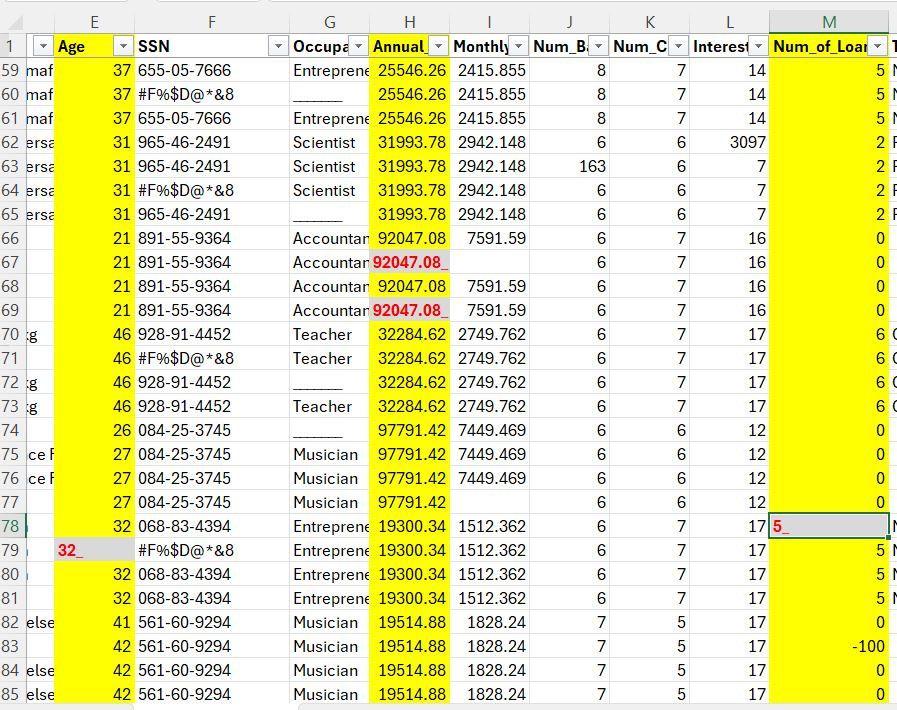

To clean columns like `Age`, `Annual_Income`, and `Num_of_Loan` where characters like underscores `(_)` appear after numeric values, we can use **string manipulation methods** to remove these unwanted characters and convert the columns to numeric types. We can run the following code:

In [40]:
# Define a function to clean numeric columns with unwanted characters
def clean_numeric_column(column):
    # Remove non-numeric characters like '_'
    return column.str.replace(r'[^0-9.]', '', regex=True).astype(float)

# Create a copy of the original credit_data to clean and save as datawithoutimputation
datawithoutimputation = credit_data.copy()

# Clean the 'Age' column
datawithoutimputation['Age'] = clean_numeric_column(datawithoutimputation['Age'])

# Clean the 'Annual_Income' column
datawithoutimputation['Annual_Income'] = clean_numeric_column(datawithoutimputation['Annual_Income'])

# Clean the 'Num_of_Loan' column
datawithoutimputation['Num_of_Loan'] = clean_numeric_column(datawithoutimputation['Num_of_Loan'])

# Verify the cleaning by checking the data types and first few rows
print("Data types after cleaning:")
print(datawithoutimputation[['Age', 'Annual_Income', 'Num_of_Loan']].dtypes)

print("\nFirst few rows after cleaning:")
print(datawithoutimputation[['Age', 'Annual_Income', 'Num_of_Loan']].head())


Data types after cleaning:
Age              float64
Annual_Income    float64
Num_of_Loan      float64
dtype: object

First few rows after cleaning:
    Age  Annual_Income  Num_of_Loan
0  23.0       19114.12          4.0
1  24.0       19114.12          4.0
2  24.0       19114.12          4.0
3  24.0       19114.12          4.0
4  28.0       34847.84          1.0


We can use the `def clean_numeric_column(column)` function to remove non-numeric characters from these specific. This function takes a column of the DataFrame as input and removes any non-numeric characters (except the decimal point .). Then, it converts the cleaned strings into floating-point numbers (`float`). The  `str.replace()` method applies a regex pattern to replace unwanted characters. Then we have to specify the `r'[^0-9.]'`, which is a regular expression (regex) that matches any character that is not a digit (`0-9`) or a decimal point (`.`). The `''` replaces the matched characters with an empty string (effectively removing them). Then, setting the `regex=True` ensures that the function treats the pattern as a regex. In the end, the function allows the conversion of the cleaned string column into a `float` by specifying the  `.astype(float)`. That is how we get numerical operations.

Then we apply the  `clean_numeric_column function` to the `Age`, `Annual_Income`, and `Num_of_Loan` columns of the data DataFrame. After cleaning, each column is overwritten with its cleaned version. Let's re-run the `info()` command now and see whether these specific columns have changed data type.

Notice that we used `datawithoutimputation = data.copy()` to create a separate copy of the dataset. This ensures that any changes, such as cleaning, are applied only to `datawithoutimputation` and do not impact the original `credit_data`. This step is essential because we will address **missing value imputation** at a later stage.

In [46]:
# Display newdataset info
datawithoutimputation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      44985 non-null  object 
 4   Age                       50000 non-null  float64
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  float64
 8   Monthly_Inhand_Salary     42502 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  float64
 13  Type_of_Loan              44296 non-null  object 
 14  Delay_

What you can see is that `Age`, `Annual_Income`, and `Num_of_Loan` are now of type `float64` (numeric).

Another important observation we can make here is that **missing values** are present in several key financial variables, which could impact downstream analysis and, therefore, would need careful handling. Let's now calculate the **number and percentage of missing values** for each column. 

In [52]:
# Calculate missing values
missing_values = credit_data.isnull().sum()

# Calculate the percentage of missing values
missing_percentage = (missing_values / len(credit_data)) * 100

# Combine into a DataFrame for better visualization
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
}).sort_values(by='Percentage (%)', ascending=False)

# Display the summary
print(missing_summary)

                          Missing Values  Percentage (%)
Monthly_Inhand_Salary               7498          14.996
Type_of_Loan                        5704          11.408
Name                                5015          10.030
Credit_History_Age                  4470           8.940
Num_of_Delayed_Payment              3498           6.996
Amount_invested_monthly             2271           4.542
Num_Credit_Inquiries                1035           2.070
Monthly_Balance                      562           1.124
Annual_Income                          0           0.000
Credit_Mix                             0           0.000
Payment_Behaviour                      0           0.000
Month                                  0           0.000
Total_EMI_per_month                    0           0.000
Payment_of_Min_Amount                  0           0.000
Age                                    0           0.000
Credit_Utilization_Ratio               0           0.000
Outstanding_Debt               

By using the `.isnull().sum()` function we are able to get an idea of the number of missing values and then by setting `len(credit_data)) * 100` we get the percentage of missing values in each column. Let's focus on 4 specific variables namely `Monthly_Inhand_Salary`, `Num_Credit_Inquiries`, `Num_of_Delayed_Payment` and `Credit_History_Age`. Among the four variables, `Monthly_Inhand_Salary` has the highest percentage of missing values, with approximately **15%** of its data missing. Following this, `Credit_History_Age` has the second highest percentage of missing values at around **9%**. The `Num_of_Delayed_Payment` variable ranks third, with approximately **7%** of its values missing. Finally, `Num_Credit_Inquiries` has the smallest percentage of missing values, with only around **2%** of its data missing.

Indeed, just by exploring the csv file we get an indication that information is missing for those variables.

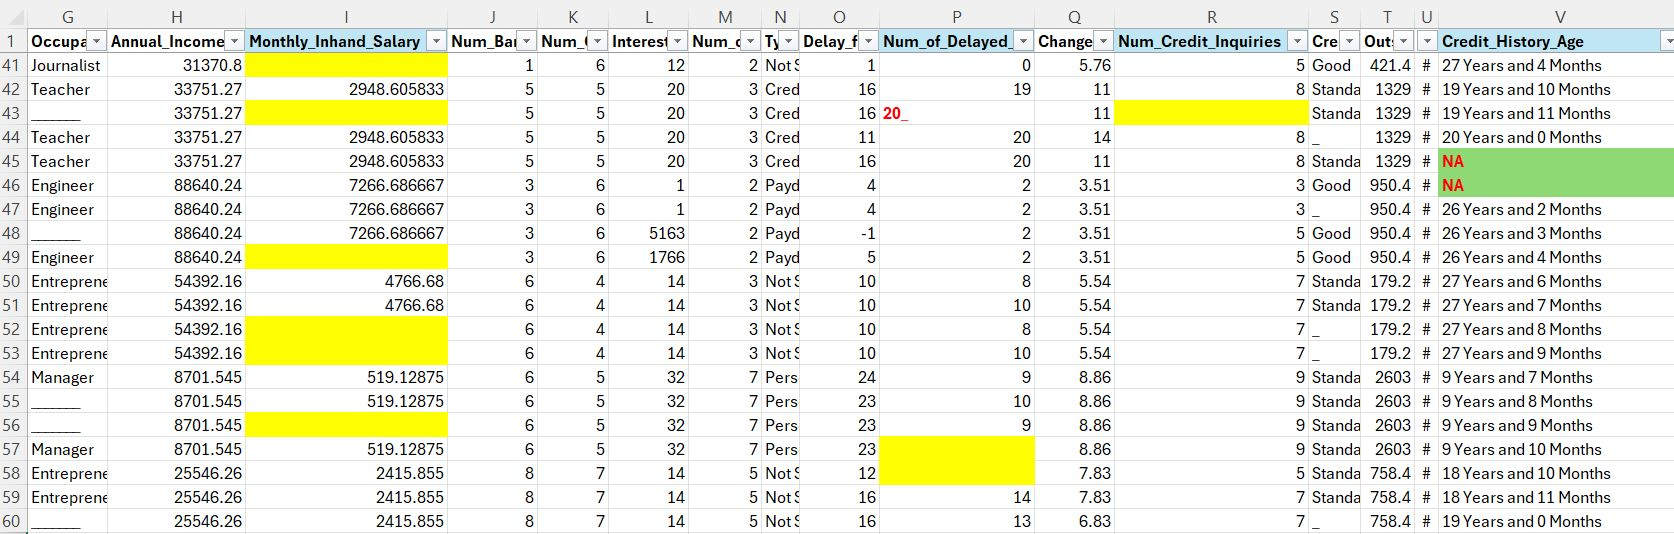

**What do you notice here?**

By exploring the data, we can observe that the `Num_of_Delayed_Payment` and `Credit_History_Age` columns contain more than just `blank cells` or `'NA'` values. The `Num_of_Delayed_Payment` column includes **non-numeric characters** like `20_`, while the `Credit_History_Age` column contains **mixed types**, such as strings like `'27 years and 4 months'`.  This is why these two columns are of type  `object`  rather than `float`.  On the contrary, the `Monthly_Inhand_Salary`, `Num_Credit_Inquiries`, contain missing values represented as blank cells in the dataset. They are of type `float` because the non-missing values are purely numeric.

Now, let's focus on treating the non-numeric and mixed-type characters appearing in the `Num_of_Delayed_Payment` and `Credit_History_Age` columns, respectively. 

The `Num_of_Delayed_Payment` column contains non-numeric characters like (`_`). We can convert this variable to a numeric (float) type by following the same procedure.

In [62]:
# Clean and convert 'Num_of_Delayed_Payment' to numeric
datawithoutimputation['Num_of_Delayed_Payment'] = datawithoutimputation['Num_of_Delayed_Payment'].str.replace(r'[^0-9]', '', regex=True).astype(float)


The `Credit_History_Age` column contains mixed type characters, so we could extract the total number of months from the text format (e.g., `"27 years and 4 Months"` → `328 months`) and then convert it to a numeric type.

In [65]:
# Function to convert 'Credit_History_Age' to total months
def convert_to_months(value):
    if pd.isnull(value):  # Handle missing values
        return None
    years = 0
    months = 0
    # Extract numeric parts safely
    if 'year' in value.lower():
        years = int(value.lower().split('year')[0].strip())
    if 'month' in value.lower():
        months_part = value.lower().split('and')[-1].strip()
        months = int(months_part.split('month')[0].strip())
    return years * 12 + months

# Apply the function to the 'Credit_History_Age' column
datawithoutimputation['Credit_History_Age'] = datawithoutimputation['Credit_History_Age'].apply(convert_to_months)

The `convert_to_months` function splits the text into `years` and `months`, multiplies years by 12, and adds months to get the total.  The `if 'year' in value.lower()` function safely checks for the presence of the word `'year'` (case insensitive), then splits the string and extracts the numeric part before `'year'`. The same procedure occurs for `month` by using the  `if 'month' in value.lower()` command. 

Let's check now the "new"  `Credit_History_Age` column

In [69]:
# Check the result
print(datawithoutimputation['Credit_History_Age'].head())

0    273.0
1    274.0
2      NaN
3    276.0
4    327.0
Name: Credit_History_Age, dtype: float64


Now let's re-run the `info()` function to indicate whether the variables have now changed type.

In [72]:
# Display info for specific columns
selected_columns = ['Monthly_Inhand_Salary', 'Num_Credit_Inquiries', 'Num_of_Delayed_Payment', 'Credit_History_Age']
datawithoutimputation[selected_columns].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Monthly_Inhand_Salary   42502 non-null  float64
 1   Num_Credit_Inquiries    48965 non-null  float64
 2   Num_of_Delayed_Payment  46502 non-null  float64
 3   Credit_History_Age      45530 non-null  float64
dtypes: float64(4)
memory usage: 1.5 MB


By applying appropriate data handling techniques, both `Num_of_Delayed_Payment` and `Credit_History_Age` were successfully converted from the `object` data type to `float`, ensuring they can now be used for numerical analysis.

In the data exploration and preparation stage, another critical step is identifying and handling **duplicates**. Duplicates can lead to biased insights or over-representation of specific data points, so detecting and addressing them ensures the integrity of the dataset for analysis.

In [76]:
# Find duplicate rows
duplicates = credit_data[credit_data.duplicated()]

# Display duplicate rows (if any)
print(f"Number of duplicate rows: {duplicates.shape[0]}")
if not duplicates.empty:
    print("Duplicate rows:")
    print(duplicates)

Number of duplicate rows: 0


The `credit_data.duplicated()` command returns a **boolean Series** indicating whether each row is a duplicate while the `duplicates.shape[0]` displays the total count of duplicate rows. Here, we can see that there are no duplicate rows which basically sets the stage for accurate analysis and modelling. 

## Exploratory Data Analysis (EDA)

Let's move now into the Exploratory Data Analysis (EDA) phase which is also  a crucial step after data exploration and preparation. In this stage, we use various techniques to gain insights into the data, identify patterns, and understand relationships between variables.

Let's look into some descriptive statistics using the `describe()` function:

In [90]:
# Summary statistics for numerical variables
datawithoutimputation.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Num_Credit_Inquiries,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month
count,50000.000000,5.000000e+04,42502.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,46502.000000,48965.000000,50000.000000,45530.000000,50000.000000
mean,118.994420,1.663342e+05,4182.004291,16.838260,22.921480,68.772640,11.299360,21.052640,30.910369,30.080200,32.279581,227.251175,1491.304305
std,678.133254,1.351965e+06,3174.109304,116.396848,129.314804,451.602363,65.483498,14.860397,221.507473,196.984121,5.106238,99.554366,8595.647887
min,14.000000,7.005930e+03,303.645417,-1.000000,0.000000,1.000000,0.000000,-5.000000,0.000000,0.000000,20.509652,10.000000,0.000000
25%,25.000000,1.945333e+04,1625.188333,3.000000,4.000000,8.000000,2.000000,10.000000,9.000000,4.000000,28.061040,151.000000,32.222388
50%,34.000000,3.757782e+04,3086.305000,6.000000,5.000000,13.000000,3.000000,18.000000,14.000000,7.000000,32.280390,225.000000,74.733349
75%,43.000000,7.281702e+04,5934.189094,7.000000,7.000000,20.000000,6.000000,28.000000,18.000000,10.000000,36.468591,307.000000,176.157491
max,8688.000000,2.413726e+07,15204.633330,1798.000000,1499.000000,5799.000000,1496.000000,67.000000,4399.000000,2593.000000,48.540663,408.000000,82398.000000


As you can see, `the data.describe()` provides statistics like `count`, `mean`, `standard deviation (std)`, `minimum (min)`, `maximum (max)`, and `percentiles` for numerical columns.

> Note at this point that the `the data.describe()` works only  on numerical columns (`float or int`). If you waant to include all comuns, even non-numerical ones, you can include the `include='all'` in the `()` in the `data.describe()` command.

We can also control the decimal places

In [92]:
# Display the rounded summary
datawithoutimputation.describe().round(2)

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Num_Credit_Inquiries,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month
count,50000.00,50000.00,42502.00,50000.00,50000.00,50000.00,50000.00,50000.00,46502.00,48965.00,50000.00,45530.00,50000.00
mean,118.99,166334.20,4182.00,16.84,22.92,68.77,11.30,21.05,30.91,30.08,32.28,227.25,1491.30
std,678.13,1351965.47,3174.11,116.40,129.31,451.60,65.48,14.86,221.51,196.98,5.11,99.55,8595.65
min,14.00,7005.93,303.65,-1.00,0.00,1.00,0.00,-5.00,0.00,0.00,20.51,10.00,0.00
25%,25.00,19453.33,1625.19,3.00,4.00,8.00,2.00,10.00,9.00,4.00,28.06,151.00,32.22
50%,34.00,37577.82,3086.30,6.00,5.00,13.00,3.00,18.00,14.00,7.00,32.28,225.00,74.73
75%,43.00,72817.02,5934.19,7.00,7.00,20.00,6.00,28.00,18.00,10.00,36.47,307.00,176.16
max,8688.00,24137255.00,15204.63,1798.00,1499.00,5799.00,1496.00,67.00,4399.00,2593.00,48.54,408.00,82398.00


The next natural step is to get a good understanding of the distribution. Let's construct the **histograms** for `Monthly_Inhand_Salary`, `Num_Credit_Inquiries`, `Num_of_Delayed_Payment` and `Credit_History_Age`.

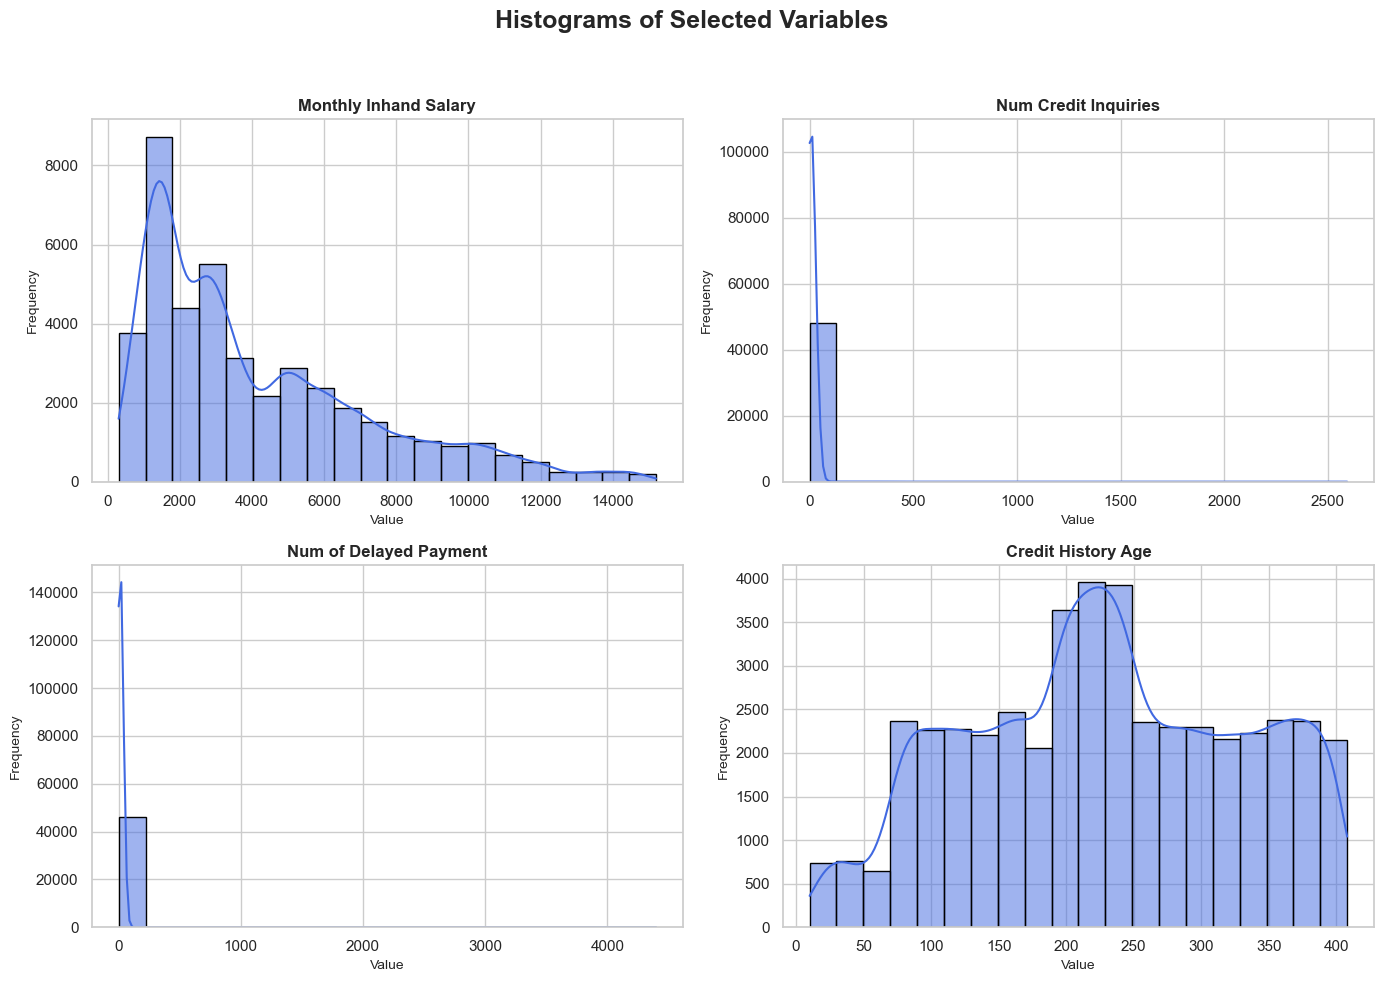

In [94]:
# List of columns to plot
columns = ['Monthly_Inhand_Salary', 'Num_Credit_Inquiries', 'Num_of_Delayed_Payment', 'Credit_History_Age']
titles = ['Monthly Inhand Salary', 'Num Credit Inquiries', 'Num of Delayed Payment', 'Credit History Age']

# Set up the style for a clean and professional look
sns.set(style="whitegrid")  # Use seaborn white grid style

# Create subplots: 2 rows, 2 columns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # Larger figure size for better presentation
fig.suptitle("Histograms of Selected Variables", fontsize=18, fontweight='bold', y=0.98)

# Loop through each column and create a histogram
for ax, col, title in zip(axes.flat, columns, titles):
    sns.histplot(datawithoutimputation[col], bins=20, kde=True, color='royalblue', edgecolor='black', ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Value', fontsize=10)  # Correct method
    ax.set_ylabel('Frequency', fontsize=10)  # Correct method

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the overall title
plt.show()

We have used the `sns.histplot()` command from the `seaborn` package. Here, we wanted to create a **2x2 grid** of subplots so all four histograms can appear in a single figure. To do this, we specify `plt.subplots(2, 2)` and then select the overall figure size for better quality using the `figsize=(14, 10)`.The `sns.histplot()` plots the histogram of the selected columns. If you want to add a **Kernel Density Estimate (KDE)** curve,  state `True` in the `kde= ()`. Then, if you want to adjust the spacing between subplots to prevent any overlap, you can use the `plt.tight_layout(rect=[])`. At the end, do not forget to apply the `plt.show()` function that renders the figure with all histograms. 

We get important information just by looking at the histograms of these four variables. 
- The distribution of the `Monthly_Inhand_Salary` is positively skewed (right-skewed). This is because **most of the data points fall within lower salary ranges**, while a **small number of individuals have significantly higher salaries**.
- Most values for `Num_Credit_Inquiries` are extremely low (`close to 0`), with a massive concentration near the origin. The majority of individuals have **very few or no credit inquiries**. The extreme values might need further **investigation for outliers**.
-  The distribution of `Num of Delayed Payment` is highly right-skewed. The significant concentration near zero suggests that delayed payments are rare for most individuals.
-  The values for `Credit_History_Age` are distributed across the range but show noticeable peaks at certain intervals, such as between 100–150, 200–250, and near 350. The multiple peaks might indicate groups of individuals with similar credit history lengths.

So, let's investigate whether these speicifc variables encounter any outliers

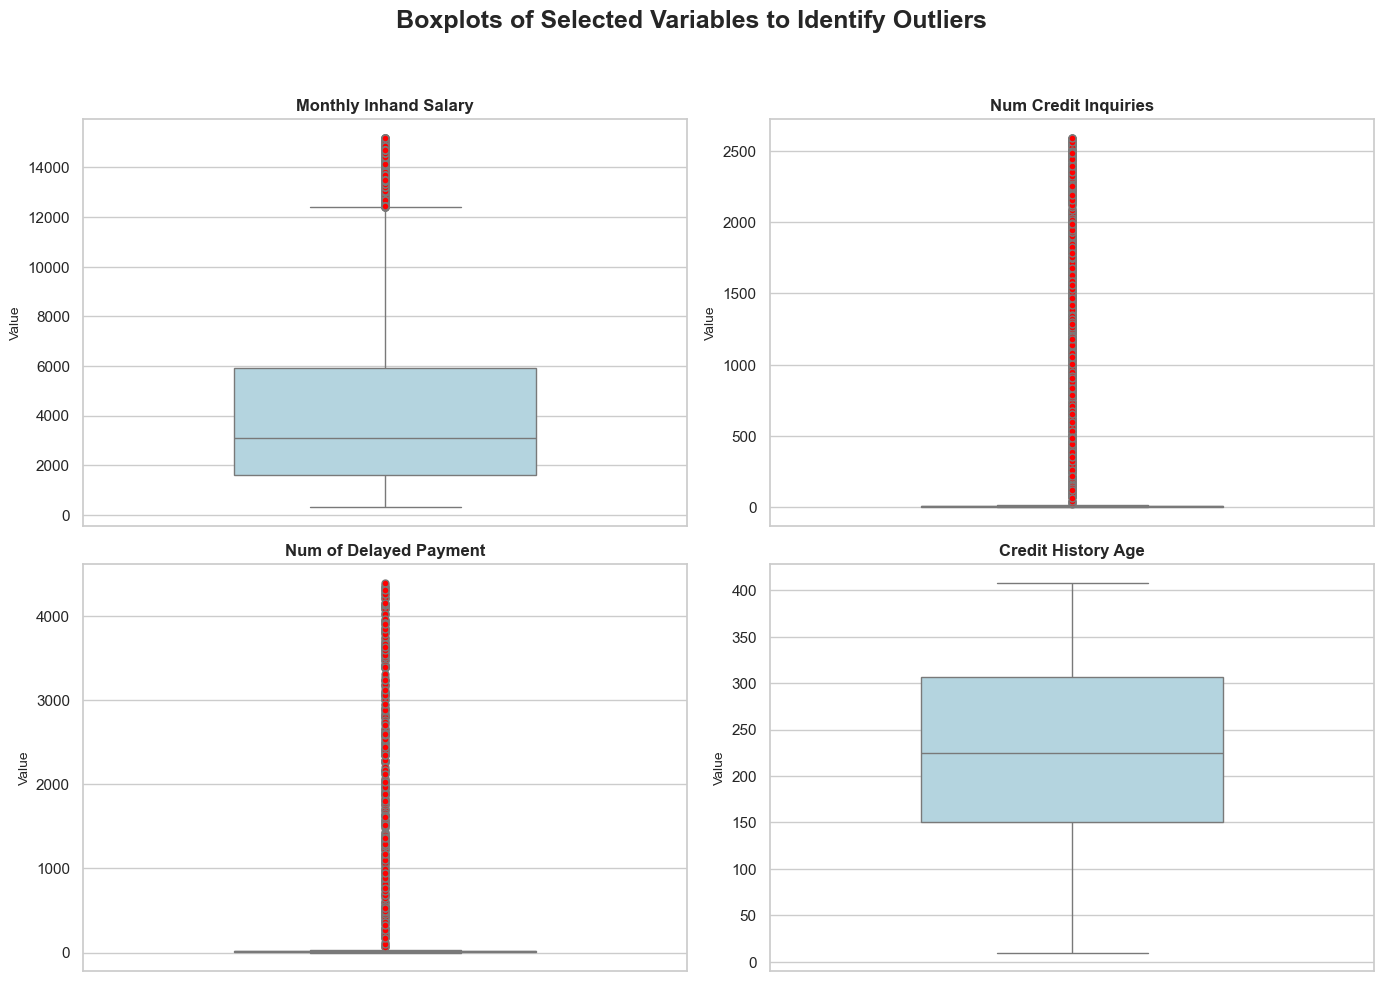

In [99]:
# List of columns and titles
columns = ['Monthly_Inhand_Salary', 'Num_Credit_Inquiries', 'Num_of_Delayed_Payment', 'Credit_History_Age']
titles = ['Monthly Inhand Salary', 'Num Credit Inquiries', 'Num of Delayed Payment', 'Credit History Age']

# Set Seaborn style
sns.set(style="whitegrid")  # Clean white grid style for better readability

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # 2 rows, 2 columns
fig.suptitle("Boxplots of Selected Variables to Identify Outliers", fontsize=18, fontweight='bold', y=0.98)

# Loop through each column and plot its boxplot
for ax, col, title in zip(axes.flat, columns, titles):
    sns.boxplot(y=datawithoutimputation[col], ax=ax, color='lightblue', width=0.5, flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 5})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Value', fontsize=10)

# Adjust layout for better spacing
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the overall title
plt.show()


To construct the boxplots for 'Monthly_Inhand_Salary', 'Num_Credit_Inquiries', 'Num_of_Delayed_Payment', 'Credit_History_Age' we can use the `sns.boxplot()` command and specify the same options as before. 

The boxplots provide critical insights into the distribution and presence of outliers for the four variables:

- **Monthly Inhand Salary**:
The distribution is right-skewed with a large number of extreme outliers above the upper whisker. Most data points are concentrated between 1,000 and 6,000, indicating that higher salaries are rare but extreme.

- **Num Credit Inquiries**:
The data is **highly skewed**, with values heavily concentrated near zero and almost all data points considered outliers. This suggests a large disparity in credit inquiry values and the presence of extreme observations.

- **Num of Delayed Payment**:
Similar to Num Credit Inquiries, this variable is **highly skewed** with a sharp concentration near zero and numerous extreme outliers stretching far beyond the upper whisker.

- **Credit History Age**:
This variable has a **balanced distribution with no significant outliers**. The data spreads evenly across the range, suggesting a more uniform and structured distribution.

Let's  assume that customers with more credit inquiries, higher length of credit history, or lower monthly salaries are more likely to delay payments. So, our **dependent variable** is `Num of Delayed Payment`, and the **independent variables** are `Credit_History_Age`, `Num_Credit_Inquiries`, and `Monthly_Inhand_Salary`.

We can plot the relationship  between the target variable and all the other variables by constructing a scatterplot. We can do this by running the `sns.scatterplot` command as follows:

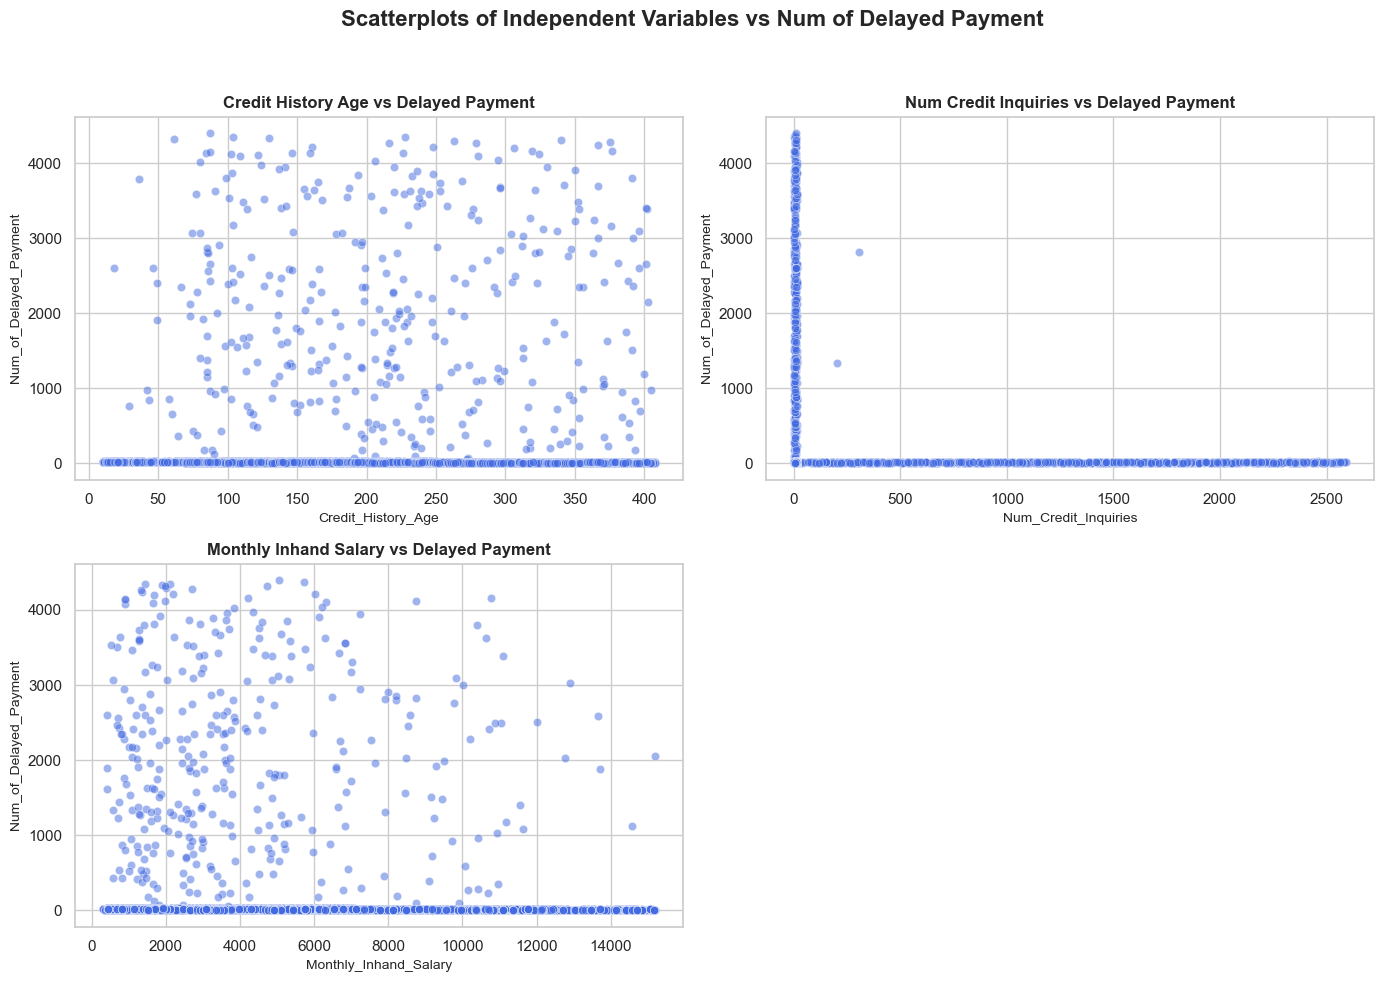

In [105]:
# Define the dependent variable and independent variables
dependent_var = 'Num_of_Delayed_Payment'
independent_vars = ['Credit_History_Age', 'Num_Credit_Inquiries', 'Monthly_Inhand_Salary']
titles = ['Credit History Age vs Delayed Payment', 
          'Num Credit Inquiries vs Delayed Payment', 
          'Monthly Inhand Salary vs Delayed Payment']

# Set Seaborn style for better presentation
sns.set(style="whitegrid")

# Create subplots: 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Scatterplots of Independent Variables vs Num of Delayed Payment", fontsize=16, fontweight='bold', y=0.98)

# Flatten axes to avoid issues with fewer plots
axes_flat = axes.flat

# Loop through each independent variable and plot
for i, (ax, ind_var, title) in enumerate(zip(axes_flat, independent_vars, titles)):
    sns.scatterplot(data=datawithoutimputation, x=ind_var, y=dependent_var, ax=ax, color='royalblue', alpha=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(ind_var, fontsize=10)
    ax.set_ylabel(dependent_var, fontsize=10)

# Hide the last subplot (since we only have 3 scatterplots)
for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])
    
# Adjust the layout to ensure no overlap
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


By looking at the scatterplots we can observe that:
- There does not appear to be a strong correlation between `Credit_History_Age` and `Num_of_Delayed_Payment`. As the credit history age increases, the delayed payments appear randomly distributed, with no clear upward or downward trend.
- There is **no clear relationship** between `Num_Credit_Inquiries` and `Num_of_Delayed_Payment`. The large concentration of points at lower values suggests that most individuals have very few credit inquiries, and this does not strongly influence delayed payments.
- There is a **weak negative relationship** between `Monthly_Inhand_Salary` and `Num_of_Delayed_Payment`. Individuals with lower salaries may be more likely to delay payments, but the relationship is not strong or linear.

Another way to explore the relationship between the variables of interest is to construct the **correlation matrix** of these numerical variables. By running the `sns.heatmap(correlation_matrix)` we get a heatmap that helps us identify realtionships nad patterns, including which variables are positively or negatively correlated. 

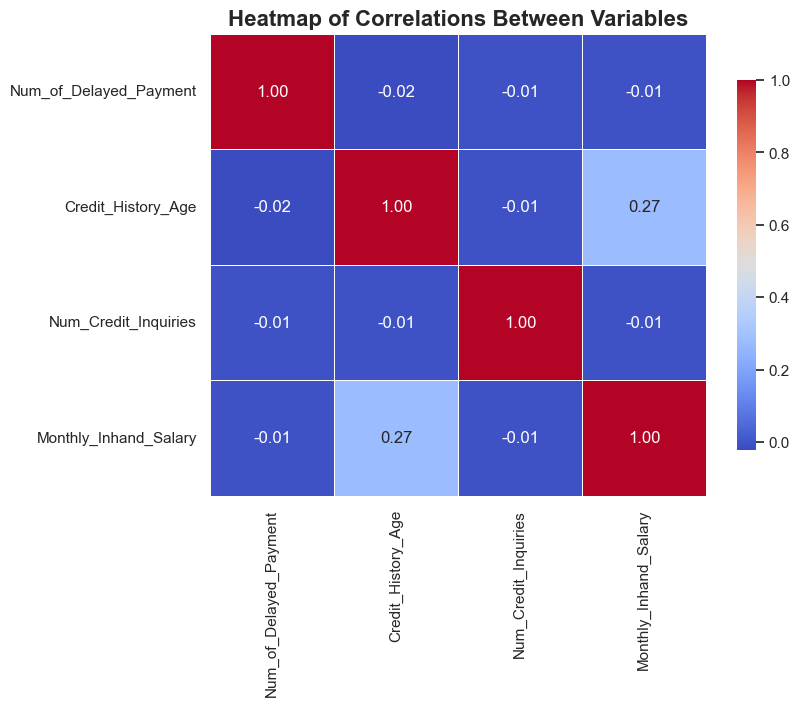

In [109]:
# Calculate the correlation matrix without 'Outstanding_Debt'
correlation_matrix = datawithoutimputation[['Num_of_Delayed_Payment', 
                                  'Credit_History_Age', 
                                  'Num_Credit_Inquiries', 
                                  'Monthly_Inhand_Salary']].corr()

# Set up the figure size
plt.figure(figsize=(8, 6))

# Create the heatmap using Seaborn
sns.heatmap(correlation_matrix, 
            annot=True,       # Show correlation values in each cell
            cmap='coolwarm',  # Use diverging color palette (red = negative, blue = positive)
            fmt=".2f",        # Display values with 2 decimal places
            linewidths=0.5,   # Add lines between cells for clarity
            cbar_kws={'shrink': 0.8})  # Adjust color bar size

# Add a title to the heatmap
plt.title("Heatmap of Correlations Between Variables", fontsize=16, fontweight='bold')

# Show the heatmap
plt.show()


We can observe that only the `Credit_History_Age` **vs** `Monthly_Inhand_Salary` relationship has a **weak positive correlation**. It suggests that individuals with a higher credit history tend to have a higher monthly income. However, the relationship is still weak.

Since linear correlations are **very low**, exploring **non-linear relationships or combining variables** (e.g., feature engineering) might help uncover deeper patterns. However, let's not forget that we haven't dealt with our missing values yet. We know that

In [113]:
# Display info for specific columns
selected_columns = ['Monthly_Inhand_Salary', 'Num_Credit_Inquiries', 'Num_of_Delayed_Payment', 'Credit_History_Age']
datawithoutimputation[selected_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Monthly_Inhand_Salary   42502 non-null  float64
 1   Num_Credit_Inquiries    48965 non-null  float64
 2   Num_of_Delayed_Payment  46502 non-null  float64
 3   Credit_History_Age      45530 non-null  float64
dtypes: float64(4)
memory usage: 1.5 MB


## Dealing with missing values

There are three popular schemes that deal with missing values:

1.	**Delete the missing values**: This course of action implies that we have **a column with over 50% missing values** and thus with so many missing values, no meaningful interpretation or relationship with the target variable will be recorded.
2.	**Keep the missing values**, because they might be meaningful.
3.	**Replace (Impute)**: This involves replacing the missing value with a known value.


> For a thorough understanding of handling  missing values and mastering data mining techniques the following resources offer valuable insights:
> - [Berry and Linoff (2004)](https://pzs.dstu.dp.ua/DataMining/bibl/Data%20Mining%20Techniques%20For%20Marketing%20Sales%20And%20Customer%20Relationship%20Management%202Ed.pdf),
> - [Wilet et al. (2020)](https://link.springer.com/article/10.1007/s11336-022-09856-8)
> -  [Coding  for Economists by Arthur Turrell](https://aeturrell.github.io/coding-for-economists/intro.html)

Once we have identified the missing values, we can then choose which scheme to implement. None of the columns of interest ( `'Monthly_Inhand_Salary', 'Num_Credit_Inquiries', 'Num_of_Delayed_Payment', 'Credit_History_Age'`) have over 50% missing values, so there is no need to delete them from the dataset. So, we are left with either imputing the missing values with a specific variable, like the `mean` or the `median`, or deciding to keep the missing values. 

From this dataset one could argue that missing values in variables like `Num_of_Delayed_Payment` or `Credit_History_Age` might indicate customers who are **new** or **inactive**. However, let's assume the missing values here do not hold meaningful information. Therefore, we can now focus on **replacing (imputing) the missing values**.

 We can proceed to a median imputation since it is robust to outliers and skewed distributions, which we observed in our earlier analysis (e.g., `Monthly_Inhand_Salary`). To perform imputation, we will need to import the `sklearn.impute`as follows:

In [122]:
from sklearn.impute import SimpleImputer

In [126]:
# Define the columns with missing values
numeric_columns = ['Num_of_Delayed_Payment', 
                   'Credit_History_Age', 
                   'Num_Credit_Inquiries', 
                   'Monthly_Inhand_Salary']

# Create a separate copy of the original data for median imputation
data_median_imputed = datawithoutimputation.copy()

# Create a SimpleImputer object with median strategy
median_imputer = SimpleImputer(strategy='median')

# Apply the imputer to the numeric columns in the copied dataset
data_median_imputed[numeric_columns] = median_imputer.fit_transform(data_median_imputed[numeric_columns])

# Verify if all missing values have been imputed
print("Missing values after median imputation:")
print(data_median_imputed[numeric_columns].isnull().sum())


Missing values after median imputation:
Num_of_Delayed_Payment    0
Credit_History_Age        0
Num_Credit_Inquiries      0
Monthly_Inhand_Salary     0
dtype: int64


The necessary step here is for you to create the "Imputer". In this case, you are creating a median imputer using `median_imputer = SimpleImputer(strategy='median')`, which replaces all missing values with the median of each column. Then you apply the imputation using the `(data_median_imputed[numeric_columns] = median_imputer.fit_transform(data_median_imputed[numeric_columns])` where `fit` calculates the median in each column and the `transform` replaces the missing values with the respective medians. Then you can confirm that all missing values have been replaced (resulting in 0 missing values) by running the `print(data_median_imputed[numeric_columns].isnull().sum())` command.

To verify this again we can run again:

In [129]:
# Display info for specific columns
selected_columns = ['Monthly_Inhand_Salary', 'Num_Credit_Inquiries', 'Num_of_Delayed_Payment', 'Credit_History_Age']
data_median_imputed[selected_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Monthly_Inhand_Salary   50000 non-null  float64
 1   Num_Credit_Inquiries    50000 non-null  float64
 2   Num_of_Delayed_Payment  50000 non-null  float64
 3   Credit_History_Age      50000 non-null  float64
dtypes: float64(4)
memory usage: 1.5 MB


You may wonder, **how has the distribution of data changed after the median- imputation**? After performing median imputation for the four variables (`Num_of_Delayed_Payment`, `Credit_History_Age`, `Num_Credit_Inquiries`, `Monthly_Inhand_Salary`), comparing the before and after **histograms** and **boxplots** is an excellent idea to visually and quantitatively verify the effect of imputation.

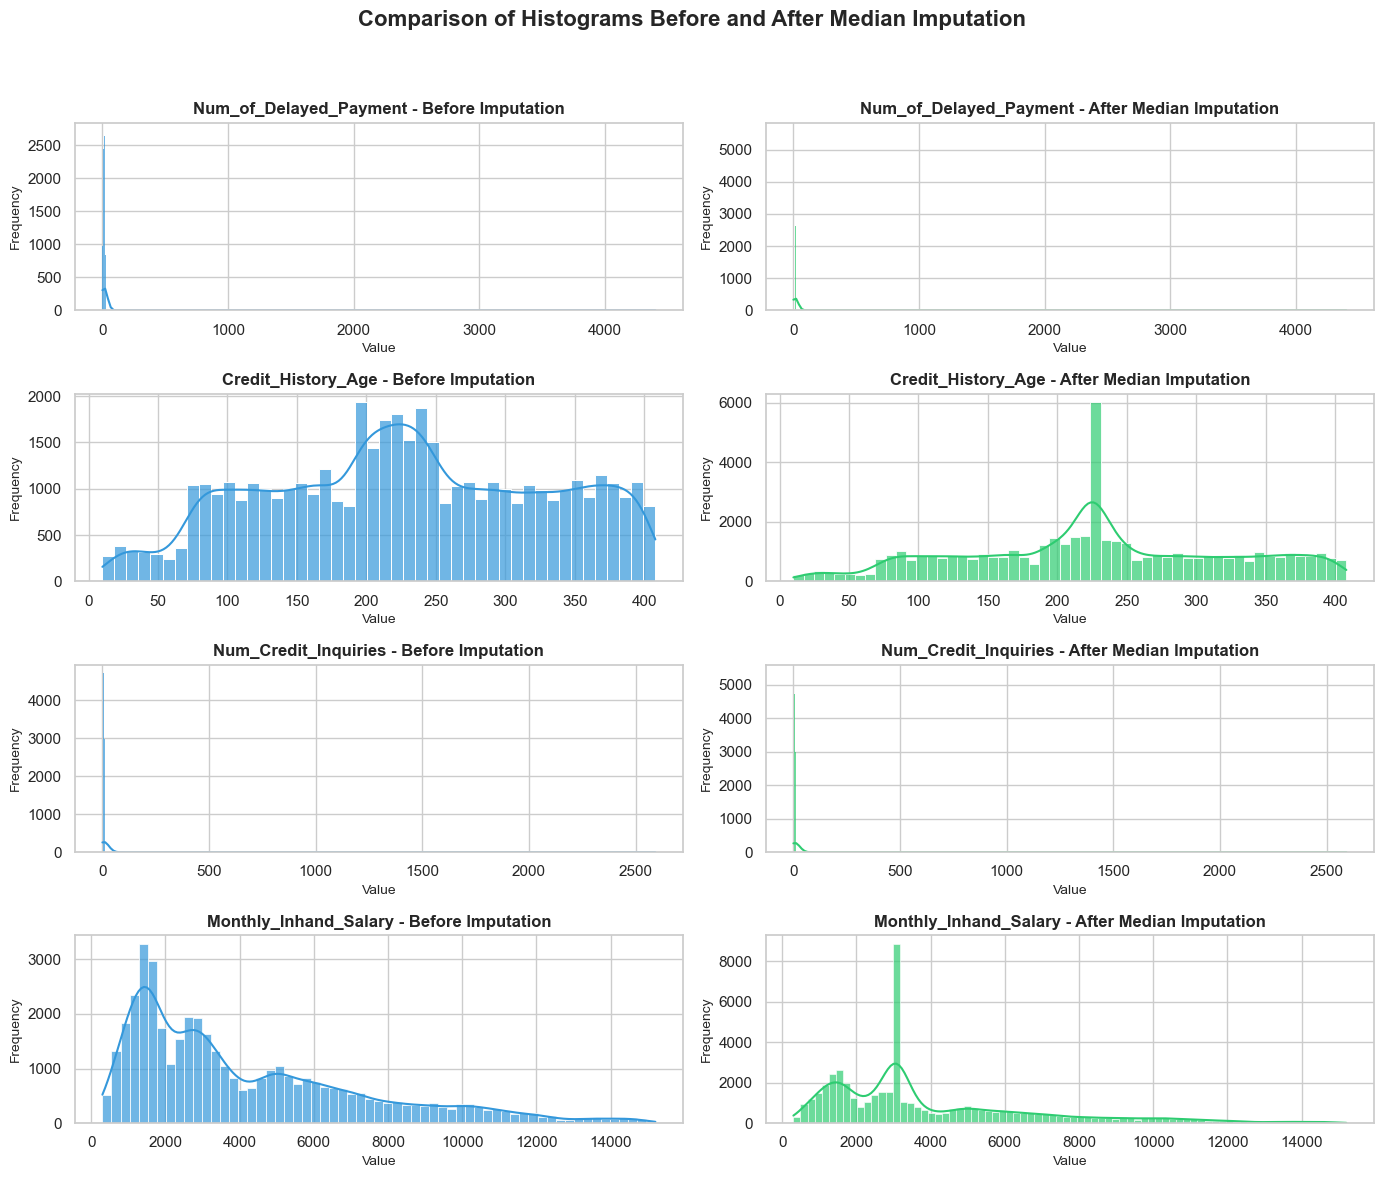

In [134]:
# List of columns to compare
columns = ['Num_of_Delayed_Payment', 'Credit_History_Age', 'Num_Credit_Inquiries', 'Monthly_Inhand_Salary']

# Define a modern Seaborn color palette
before_color = "#3498DB"  # Soft Blue (Before Imputation)
after_color = "#2ECC71"   # Soft Green (After Imputation)

# Create subplots for before and after histograms
fig, axes = plt.subplots(4, 2, figsize=(14, 12))  # 4 rows, 2 columns
fig.suptitle("Comparison of Histograms Before and After Median Imputation", 
             fontsize=16, fontweight='bold', y=0.98)

# Loop through each column
for i, col in enumerate(columns):
    # Before Imputation: Plot histogram
    sns.histplot(datawithoutimputation[col].dropna(), kde=True, ax=axes[i, 0], color=before_color, alpha=0.7)
    axes[i, 0].set_title(f"{col} - Before Imputation", fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel("Value", fontsize=10)
    axes[i, 0].set_ylabel("Frequency", fontsize=10)

    # After Imputation: Plot histogram
    sns.histplot(data_median_imputed[col], kde=True, ax=axes[i, 1], color=after_color, alpha=0.7)
    axes[i, 1].set_title(f"{col} - After Median Imputation", fontsize=12, fontweight='bold')
    axes[i, 1].set_xlabel("Value", fontsize=10)
    axes[i, 1].set_ylabel("Frequency", fontsize=10)

# Improve the spacing and ensure readability
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Here we have created subplots for the histograms before and after the median imputation. The `plt.subplots(4, 2, figsize=(14, 12))` creates a grid  of 4 rows and 2 columns becayse we are dealing with 4 variables. The `for i, col in enumerate(columns)` basically iterates over each variables in the `columns` list. Here you are looping through columns! The `sns.histplot()` command allows us to plot the distribution of the values using `Seaborn`. If you want to add a smooth density curve to show the shape of the distribution you can set `True` in the `kde=`. We follow than then same process  for the other dataset named `data_median_impputed`. 

Comparing the histograms side-by-side we get some valuable information:
- The histogram for `Num_of_Delayed_Payment` before imputation shows a large concentration of values at the lower end (close to 0). Now, after replacing the missing values with the `median` a spike is visible where it was imputed. However, we can see that the overall distribution remains intact, with no significant distortion beyond the imputed median.
- The histogram for `Credit_History_Age` shows a relatively uniform spread of the values, with some gaps caused by missing values. While the imputation has filled gaps, it has introduced a central concentration of values around the median, which is quite common with median imputation for continuous data.
- The  `Num_Credit_Inquiries` distribution before imputation is highly skewed to the right, however after imputation the overall skenwess remains intact.
- The same could be observed for the `Monthly_Inhand_Salary` showing that median imputation works well for this skewed data, as it avoids distortions caused by outliers.

# Advanced Imputation techniques

While median imputation works well here, it’s worth noting that Python offers a variety of powerful methods to deal with missing data. One of these methods involves the `K-Nearest Neighbors (KNN`) Imputation using  `KNNImputer` from `sklearn`. This imputation technique estimates missing values based on the values of the nearest neighbours. 


To understand how the K-Nearest Neighbours (KNN) imputation technique actually works let's assume that you are estimating the **income of a person (with a missing income value)** based on his **credit inquiries, the length of credit history, and his delayed payments**.

For each observation where `Monthly_Inhand_Salary` is missing:
- KNN looks for the 5 most similar observations (neighbours) based on `Credit_History_Age`, `Num_Credit_Inquiries` and `Monthly_Inhand_Salary`.
- For example:
  - Missing Value: Num_of_Delayed_Payment = `?`
  - Nearest neighbours have: `Num_of_Delayed_Payment` = `10`, `12`, `11`, `10`, `12`.
- KNN calculates the average of the neighbours’ values:

$$ Imputed \ Value=
\frac{10 + 12 + 11 + 10 + 12}{5} = 11
$$

- The missing value is replaced with **11**.

To implement KNN Imputation and then visually compare the results with the dataset before imputation (`datawithoutimputation`) and after KNN Imputation, we will follow these steps:

- Use the `KNNImputer` from the `sklearn.impute` module to **fill** the missing values and create a separate dataset for KNN imputed data.
- Plot histograms to compare before and after KNN imputation.

### First step: Fill missing values using `KNNImputer` from the `sklearn.impute`

In [153]:
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns to impute
columns_to_impute = ['Num_of_Delayed_Payment', 'Credit_History_Age', 'Num_Credit_Inquiries', 'Monthly_Inhand_Salary']

# Create a copy of the original data for KNN Imputation
data_knn_imputed = datawithoutimputation.copy()

# Initialize KNNImputer
knn_imputer = KNNImputer(n_neighbors=5, weights='uniform')  # 5 nearest neighbors

# Apply KNN Imputer
data_knn_imputed[columns_to_impute] = knn_imputer.fit_transform(data_knn_imputed[columns_to_impute])

# Verify if missing values have been imputed
print("Missing values after KNN Imputation:")
print(data_knn_imputed[columns_to_impute].isnull().sum())

Missing values after KNN Imputation:
Num_of_Delayed_Payment    0
Credit_History_Age        0
Num_Credit_Inquiries      0
Monthly_Inhand_Salary     0
dtype: int64


The `n_neighbors=5` in the `KNNImputer` function measn that it uses the average of the 5 nearest neighbors to impute missing values whereas the `weights='uniform'` indicates that all neighbours contribute equally to the imputation. It is important to create a separate dataset for the KNN Imputation so we can compare it to the original one. What actually applies the KNN imputer to the selected columns is the `fit_transform()` command. From the outpu provided, we can see that with the KNN imputation, the number of missing values for the variables on interest is zero.

### Second step: Plot histograms to compare before and after KNN imputation

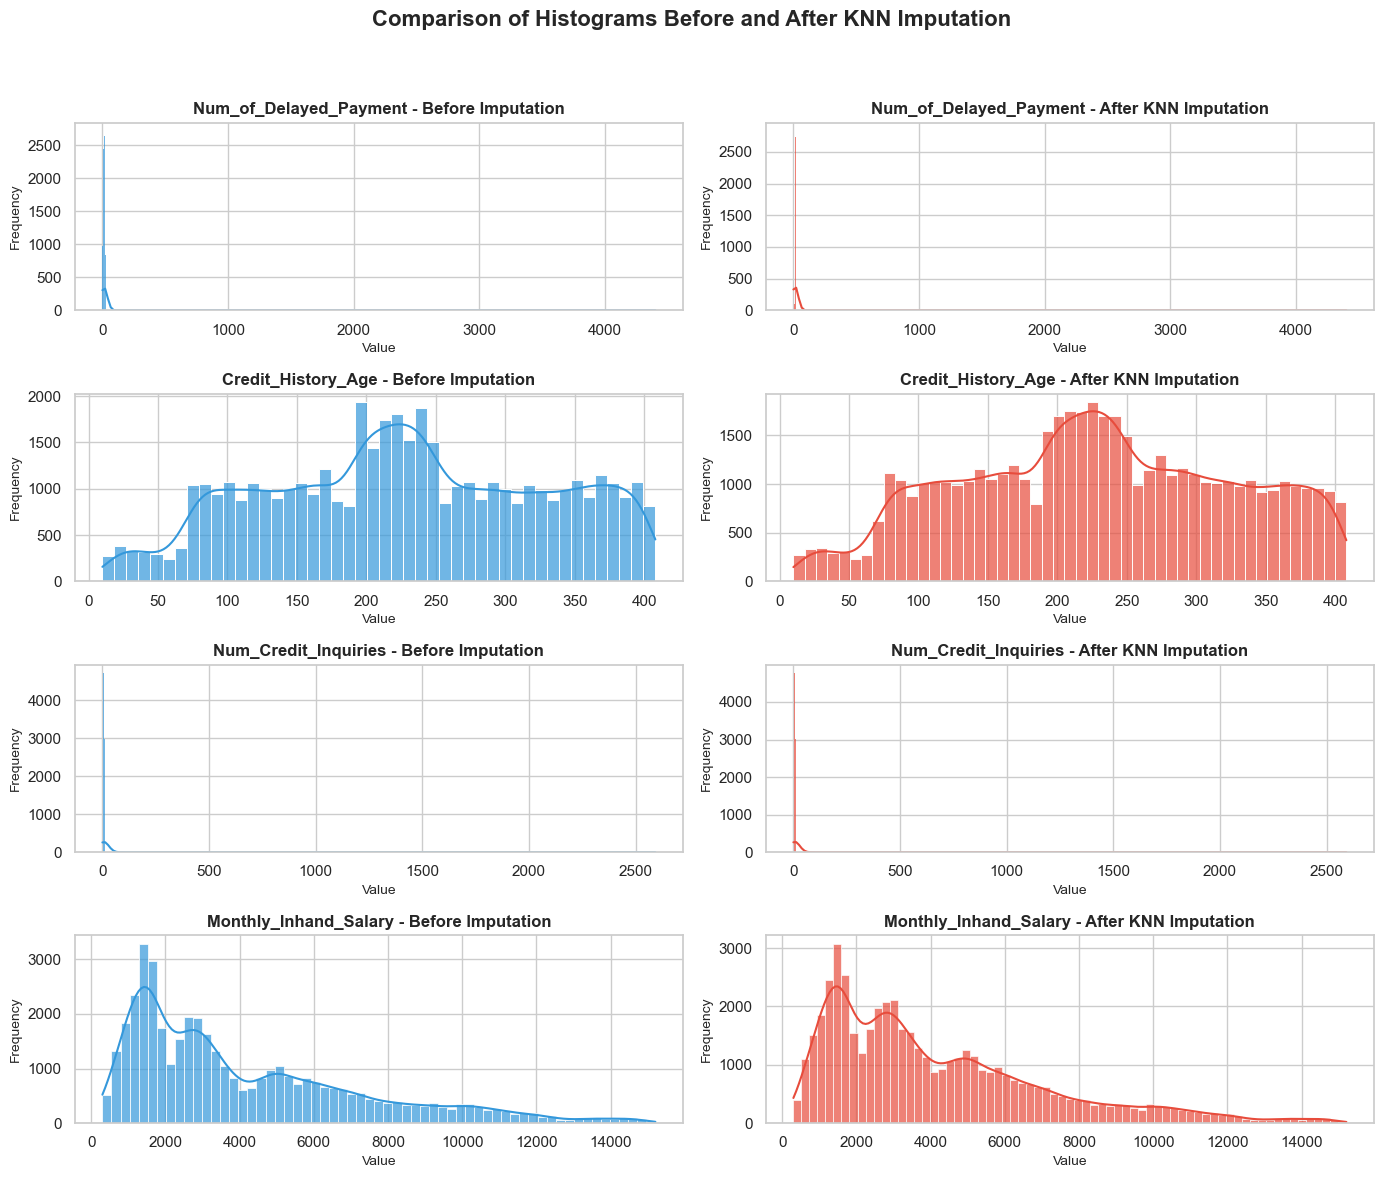

In [158]:
# Compare Histograms Before and After KNN Imputation
fig, axes = plt.subplots(4, 2, figsize=(14, 12))  # 4 rows, 2 columns
fig.suptitle("Comparison of Histograms Before and After KNN Imputation", fontsize=16, fontweight='bold', y=0.98)

# Define colors
before_color = "#3498DB"  # Blue for before imputation
after_color = "#E74C3C"   # Red for after KNN imputation

# Loop through each column
for i, col in enumerate(columns_to_impute):
    # Plot Before Imputation
    sns.histplot(datawithoutimputation[col].dropna(), kde=True, ax=axes[i, 0], color=before_color, alpha=0.7)
    axes[i, 0].set_title(f"{col} - Before Imputation", fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel("Value", fontsize=10)
    axes[i, 0].set_ylabel("Frequency", fontsize=10)

    # Plot After KNN Imputation
    sns.histplot(data_knn_imputed[col], kde=True, ax=axes[i, 1], color=after_color, alpha=0.7)
    axes[i, 1].set_title(f"{col} - After KNN Imputation", fontsize=12, fontweight='bold')
    axes[i, 1].set_xlabel("Value", fontsize=10)
    axes[i, 1].set_ylabel("Frequency", fontsize=10)

# Adjust the layout for readability
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Now that we have plotted the histograms before and after KNN imputation, it’s your turn to take the lead! Take this opportunity to critically interpret the results and strengthen your understanding of imputation techniques.

# Summary

In this section, we demonstrated key data preprocessing steps to ensure the dataset is clean, complete, and ready for analysis. Beginning with **data exploration and preparation**, we identified issues such as incorrect data types and missing values, which were resolved through data cleaning and conversion into appropriate numeric formats. During **exploratory data analysis (EDA)**, we examined variable distributions, identified outliers using histograms and boxplots, and explored relationships through scatterplots and a correlation heatmap, revealing weak correlations between variables. Finally, we **addressed missing values** using median and the KNN Imputation,  robust approaches suited for skewed data and outliers. These preprocessing steps have systematically prepared the dataset for the next phase of analysis or modelling, ensuring its integrity and reliability.